In [439]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from matplotlib.colors import ListedColormap
from ppu.generator import Circular, GaussianBlobs, Moons, RingBlobs
from ppu.methods.mlp import MLP
from ppu.methods.tracin import get_random_resampled_tracin, get_random_tracin
from ppu.methods.utils import get_dataset, get_models
from ppu.viz.tracin_plot import draw
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.inspection._plot.decision_boundary import _check_boundary_response_method

In [468]:
def get_gradnorm(X_grid, labels, nn, layers, temperature=1., norm=1):
    gn = []
    for point in X_grid:
        ws = []
        for label in labels:
            nn.optimizer.zero_grad()
            X_test = torch.tensor(np.array(point)).to(torch.float32)
            label_test = torch.tensor(label).to(torch.float32)
            nn.criterion(nn.model(X_test).squeeze(-1)/temperature, label_test).backward()
            iters  = np.array(layers) * 2 - 2
            w = None
            for i in iters:
                layer = list(nn.model.parameters())[i].grad.reshape(-1)
                w = layer if w is None else np.concatenate((w, layer))
            ws.append(np.linalg.norm(w, ord=norm))
        w_sum = sum(ws)
        gn.append((w_sum)/len(labels))
    return np.array(gn)


In [555]:
classifier = MLP(hidden_channels=[30, 100, 200, 100, 50, 50, 20, 1], patience=5, frequency=3, lr=1e-2, device="cpu")

n_ticks = 100
n_samples = 2000  #train instances


generator = {
    "GaussianBlobs" : GaussianBlobs,
    "Circular" : Circular,
    "Moons" : Moons,
    "RingBlobs" : RingBlobs
}

In [562]:
gen = RingBlobs
seed = 1
sep = 18

data = get_dataset(seed, gen, n_samples=n_samples, class_sep=sep)
nn  = get_models(classifier, gen, reps=1, n_samples=n_samples, seeds=[seed], class_sep=sep)[0]

In [563]:
(X_train, y_train), (X_test, y_test) = data
eps = 1.
x_min, x_max = X_train[:, 0].min() - eps, X_train[:, 0].max() + eps
y_min, y_max = X_train[:, 1].min() - eps, X_train[:, 1].max() + eps

x = np.linspace(
        x_min, x_max, n_ticks
    )  # for the heatmap we need to creat the grid first, so n_ticks are the density of the grid nodes
y = np.linspace(y_min, y_max, n_ticks)
xs, ys = np.meshgrid(x, y)
X_grid = np.c_[xs.ravel(), ys.ravel()]

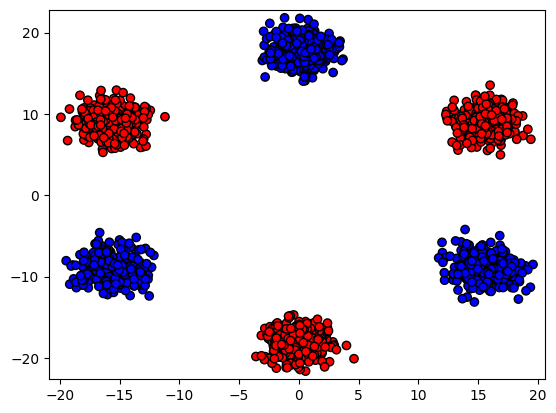

In [564]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(["#FF0000", "#0000FF"]), edgecolors="k")
plt.xlim(x_min, x_max)  # axis range
plt.ylim(y_min, y_max)
plt.show()

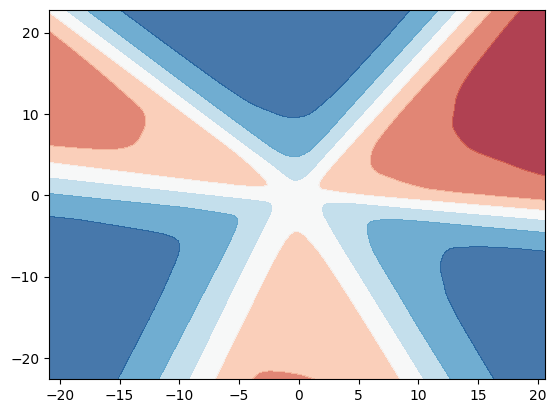

In [565]:
response = _check_boundary_response_method(nn, "auto")(
    X_grid
)  # the function returns the probability of points(inputs) belong to each class

if len(response.shape) != 1:
    response = response[
        :, 1
    ]  # since there's only 2 classes so 1 can represent the other(the prob sums up to 1)


cm = plt.cm.RdBu
display = DecisionBoundaryDisplay(
    xx0=xs, xx1=ys, response=response.reshape(xs.shape)
)  # class to draw DecisionBoundary
display.plot(cmap=cm, alpha=0.8)

In [566]:
labels = [0, 1]

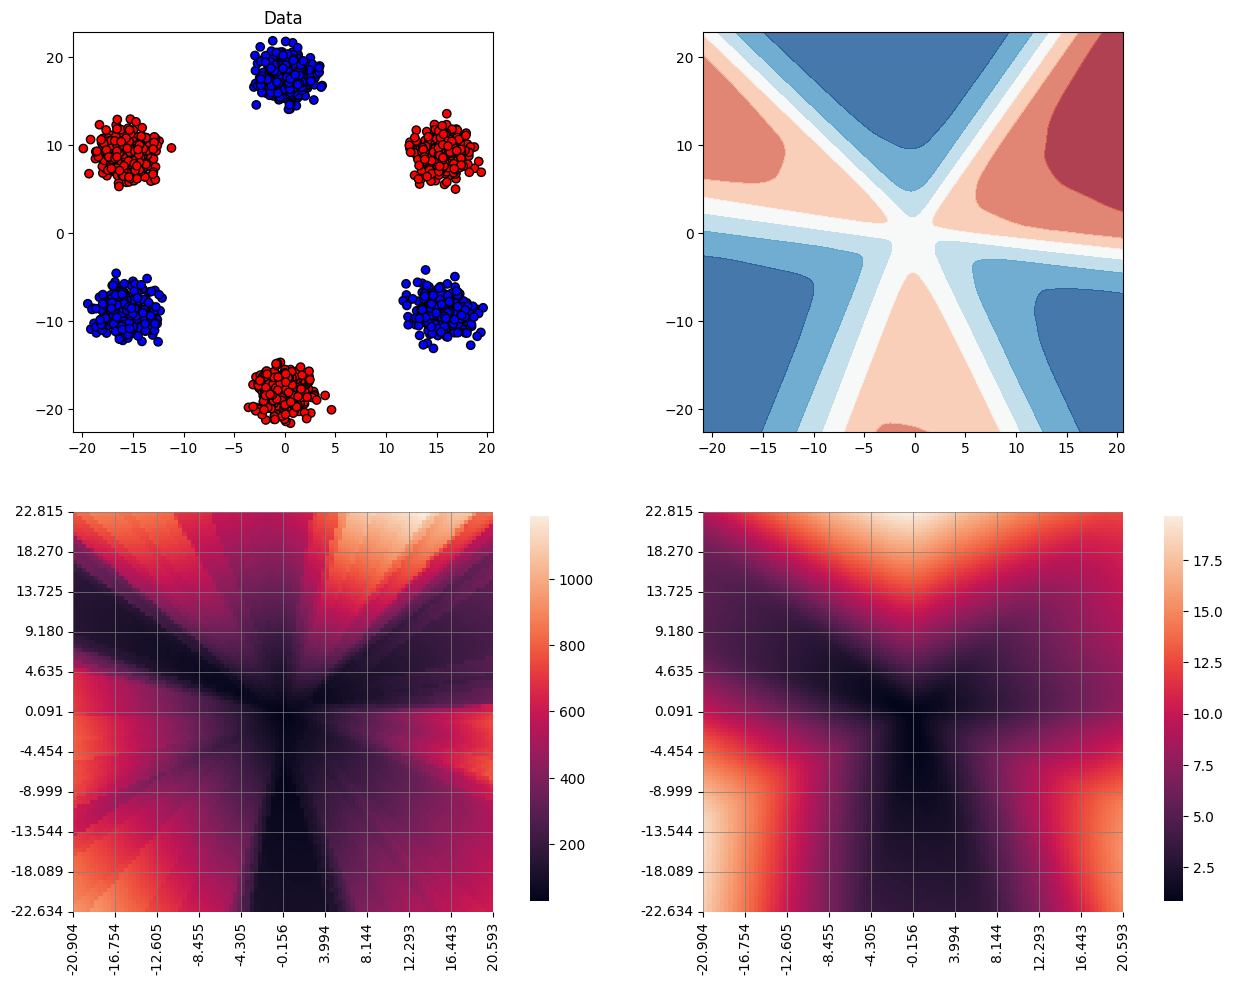

In [567]:
figure, axs = plt.subplots(2, 2, figsize=(15, 11))
cm_bright = ListedColormap(["#FF0000", "#0000FF"])  # color for data points
ax = axs[0][0]  # position of subgraph
ax.set_title("Data")  # subgraph title
# Plot the training points
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
ax.set_xlim(x_min, x_max)  # axis range
ax.set_ylim(y_min, y_max)

ax = axs[0][1]
response = _check_boundary_response_method(nn, "auto")(
    X_grid
)  # the function returns the probability of points(inputs) belong to each class

if len(response.shape) != 1:
    response = response[
        :, 1
    ]  # since there's only 2 classes so 1 can represent the other(the prob sums up to 1)


cm = plt.cm.RdBu
display = DecisionBoundaryDisplay(
    xx0=xs, xx1=ys, response=response.reshape(xs.shape)
)  # class to draw DecisionBoundary
display.plot(cmap=cm, alpha=0.8, ax=ax)

all_layers = [i+1 for i in range(8)]
gn = get_gradnorm(X_grid, labels, nn, all_layers)
gn = gn.reshape(xs.shape)
ax = axs[1][0]
draw(gn, x, y, ax=ax)

last_layer = [8]
gn_ll = get_gradnorm(X_grid, labels, nn, last_layer)
gn_ll = gn_ll.reshape(xs.shape)
ax = axs[1][1]
draw(gn_ll, x, y, ax=ax)
'''ax = axs[1][1]
draw(tracin_1_20, x, y, ax=ax)
ax = axs[1][2]
draw(tracin_20, x, y, ax=ax)'''



plt.subplots_adjust(left=0.12,
        bottom=0.1,
        right=0.82,
        top=0.9,
        wspace=0.5,
        hspace=0.2,
    )